# 03 — Test des 5 modèles de classification

**Objectif :** comparer 5 modèles pour prédire `Churn` : Logistic Regression, Decision Tree, Random Forest, SVM et Gradient Boosting.

**Ce notebook est volontairement court :** pas de traitement du déséquilibre, pas de variable `cluster`, pas d'optimisation. Il ne dépend pas du notebook de clustering (il utilise seulement `src/preprocessing.py`).

**Règles respectées**
- `Churn` n'est jamais dans `X`.
- Imputation, standardisation et encodage sont dans un `Pipeline` : ajustés uniquement sur le train.
- La comparaison se fait par **validation croisée sur le train** ; le **test** sert à l'évaluation finale.

## 1. Imports et données

In [ ]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import prepare, load_data, train_test, TARGET
from src.models import build_pipeline, build_baseline, MODEL_NAMES
from src.evaluate import stratified_cv, cv_scores, test_metrics, plot_confusions, plot_roc

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

X_train, X_test, y_train, y_test = train_test(prepare(load_data()))   # split stratifié, avant tout fit
assert TARGET not in X_train.columns and TARGET not in X_test.columns
print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("Churn train : %.3f | test : %.3f" % (y_train.mean(), y_test.mean()))

X_train : (5634, 22) | X_test : (1409, 22)
Churn train : 0.265 | test : 0.265


## 2. Métriques et baseline

On regarde la classe **Churn** (celle qu'on veut détecter) :

| Métrique | Question |
|---|---|
| **Precision** | Parmi les clients prédits "churn", quelle part part vraiment ? |
| **Recall** | Parmi ceux qui partent vraiment, quelle part détecte-t-on ? |
| **F1** | Compromis entre Precision et Recall |
| **ROC-AUC** | Capacité à classer les clients par risque, indépendamment du seuil |
| **Matrice de confusion** | Nombre de bonnes détections, de clients manqués et de fausses alertes |

**Baseline :** un modèle qui prédit toujours "reste". C'est le plancher à dépasser.

In [2]:
cv = stratified_cv(n_splits=5)      # 5 plis stratifiés, sur le train
base = cv_scores(build_baseline(), X_train, y_train, cv)
pd.Series({k: round(v, 3) for k, v in base.items() if not k.endswith("_std")}, name="baseline (CV)").to_frame().T

,accuracy,precision,recall,f1,roc_auc
baseline (CV),0.735,0.0,0.0,0.0,0.5


**Lecture :** la baseline atteint ≈ 73,5 % d'accuracy sans rien apprendre, mais son Recall est de 0 : elle ne détecte aucun client qui part. L'accuracy seule est donc trompeuse ici (≈ 26,5 % de churn).

## 3. Les 5 modèles : validation croisée sur le train

Chaque modèle est un `Pipeline` (preprocessing → modèle), avec des réglages raisonnables par défaut (l'optimisation viendra plus tard).

In [3]:
rows = []
for name in MODEL_NAMES:
    res = cv_scores(build_pipeline(name, "none"), X_train, y_train, cv)
    res["model"] = name
    rows.append(res)
cv_table = pd.DataFrame(rows).set_index("model")
cv_table[["accuracy", "precision", "recall", "f1", "roc_auc", "f1_std", "roc_auc_std"]].round(3)

,accuracy,precision,recall,f1,roc_auc,f1_std,roc_auc_std
model,,,,,,,
Logistic Regression,0.805,0.666,0.533,0.592,0.846,0.024,0.011
Decision Tree,0.791,0.620,0.555,0.583,0.829,0.024,0.011
Random Forest,0.792,0.643,0.489,0.555,0.828,0.024,0.010
SVM,0.800,0.683,0.468,0.554,0.802,0.014,0.019
Gradient Boosting,0.799,0.656,0.515,0.577,0.847,0.017,0.012


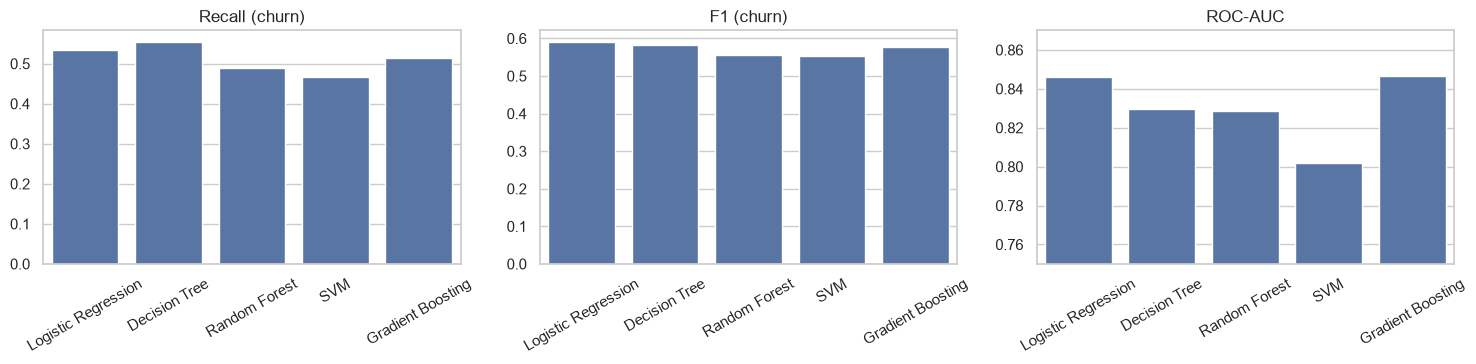

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, metric, title in zip(axes, ["recall", "f1", "roc_auc"], ["Recall (churn)", "F1 (churn)", "ROC-AUC"]):
    sns.barplot(x=cv_table.index, y=cv_table[metric], color="#4C72B0", ax=ax)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=30)
    if metric == "roc_auc": ax.set_ylim(0.75, 0.87)
plt.tight_layout(); plt.show()

## 4. Évaluation sur le test

Chaque modèle est ré-entraîné sur tout le train puis évalué **une seule fois** sur le test.

In [5]:
fitted = {name: build_pipeline(name, "none").fit(X_train, y_train) for name in MODEL_NAMES}

rows = {name: test_metrics(pipe, X_test, y_test) for name, pipe in fitted.items()}
rows["Baseline (toujours 'reste')"] = test_metrics(build_baseline().fit(X_train, y_train), X_test, y_test)
pd.DataFrame(rows).T.round(3).sort_values("roc_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc
Gradient Boosting,0.802,0.667,0.508,0.577,0.843
Logistic Regression,0.799,0.654,0.516,0.577,0.842
Decision Tree,0.799,0.632,0.583,0.606,0.833
Random Forest,0.784,0.621,0.481,0.542,0.828
SVM,0.796,0.663,0.468,0.549,0.803
Baseline (toujours 'reste'),0.735,0.000,0.000,0.000,0.500


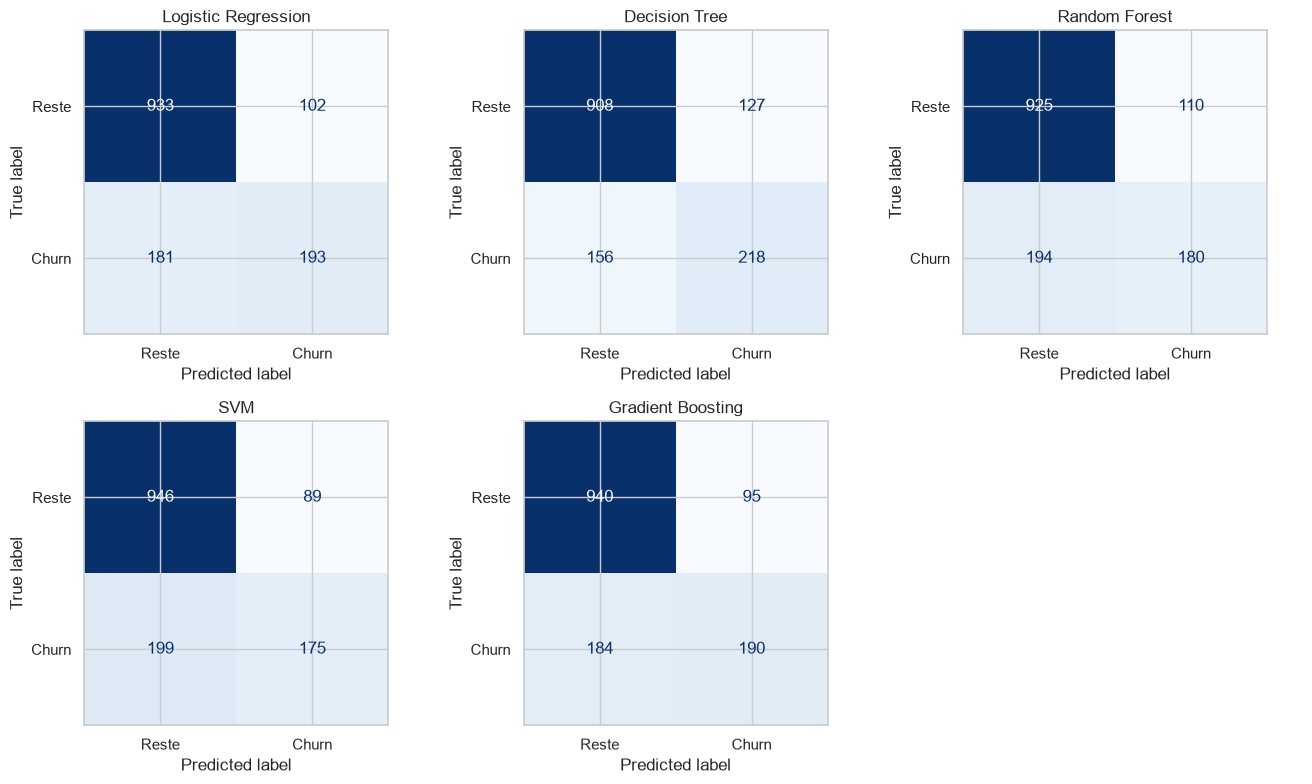

In [6]:
plot_confusions(fitted, X_test, y_test, ncols=3)

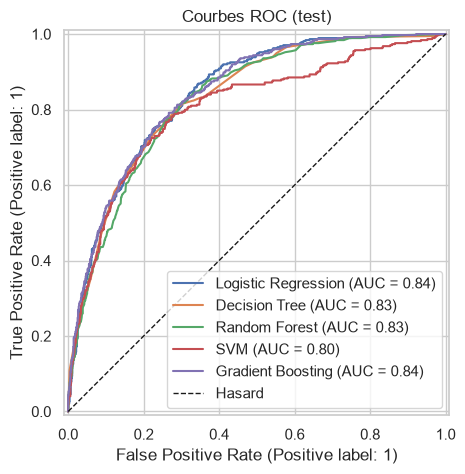

In [7]:
plot_roc(fitted, X_test, y_test)

## 5. Lecture et conclusion

**Validation croisée (train) et test donnent la même image :**
- Tous les modèles dépassent la baseline en accuracy (≈ 0,78 à 0,80 contre 0,735), mais ils ne détectent qu'environ **la moitié des clients qui partent** (Recall ≈ 0,47 à 0,58) avec une Precision de 0,62 à 0,68. Environ un client sur deux qui part n'est pas repéré.
- **ROC-AUC** : Gradient Boosting et Logistic Regression sont en tête (≈ 0,84), suivis du Decision Tree et du Random Forest (≈ 0,83). Le SVM est le plus faible (≈ 0,80).
- **F1** : de 0,54 à 0,61 sur le test. Les écarts entre modèles sont petits par rapport au bruit de la validation croisée (écart-type ≈ 0,02) : ne pas surinterpréter. Le Decision Tree a le meilleur F1 sur ce test (≈ 0,61) mais pas en validation croisée, et son ROC-AUC est plus faible : on ne le retient pas sur ce seul résultat.

**Conclusion :** **Logistic Regression** et **Gradient Boosting** sont les deux meilleurs candidats (meilleur ROC-AUC, résultats stables). Le Recall d'environ 50 % est le point faible commun : il s'explique par le déséquilibre des classes (≈ 26,5 % de churn), que ces modèles n'ont pas encore reçu comme consigne de corriger.

**Pistes pour la suite (hors de ce notebook) :** `class_weight` ou SMOTE pour relever le Recall, réglage des hyperparamètres (validation croisée + `GridSearchCV`), et choix du seuil de décision.